#  Credit Card Fraud Detection

##  Project Overview
This project aims to detect fraudulent credit card transactions using machine learning on a highly imbalanced dataset. The data consists of anonymized features (V1–V28), transaction time, amount, and a target variable indicating fraud.

##  Methodology
The workflow includes exploratory data analysis (EDA), data preprocessing, handling class imbalance using SMOTE, and training multiple models including Logistic Regression, Random Forest, XGBoost, and Isolation Forest.

##  Evaluation Metrics
Model performance is evaluated using metrics suitable for imbalanced data, such as Precision, Recall, F1-score, Precision-Recall Curve (PR-AUC), and ROC-AUC.

##  Objective
The goal is to identify the most effective model for detecting fraud while minimizing missed fraudulent transactions.

In [1]:
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "1"

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve, roc_curve,
    average_precision_score, roc_auc_score,
    precision_score, recall_score, f1_score
)

# Imbalanced-learn (SMOTE)
from imblearn.over_sampling import SMOTE

# XGBoost
from xgboost import XGBClassifier

In [3]:
df = pd.read_csv("C:/Users/sharm/Downloads/creditcard.csv/creditcard.csv")
print(f"Shape: {df.shape}")

Shape: (284807, 31)


In [4]:
print("n1. SHAPE:")
print(f"   Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")

print("\n2. DATA TYPES:")
print(df.dtypes)

print("\n3. NULL VALUES:")
null_count = df.isnull().sum()
if null_count.sum() == 0:
    print("   No missing values found. Dataset is clean!")
else:
    print(null_count[null_count > 0])

print("\n4. BASIC STATISTICS:")
print(df[["Time", "Amount", "Class"]].describe())

n1. SHAPE:
   Rows: 284,807 | Columns: 31

2. DATA TYPES:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

3. NULL VALUES:
   No missing values found. Dataset is clean!

4. BASIC STATISTICS:
                Time         Amount          Class
count  284807.000000  284807.000000  284807.000000
mean    94813.859575      88.349619       0.001727
std     47488.145955     250.120109       0.041527
min         0.000000       0.000000       0.000000
25%     54201.500000       5.6


>> Class Distribution:
   Normal (0): 284,315 transactions (99.83%)
   Fraud  (1): 492 transactions (0.1727%)

   Imbalance Ratio: 577:1 (Normal:Fraud)


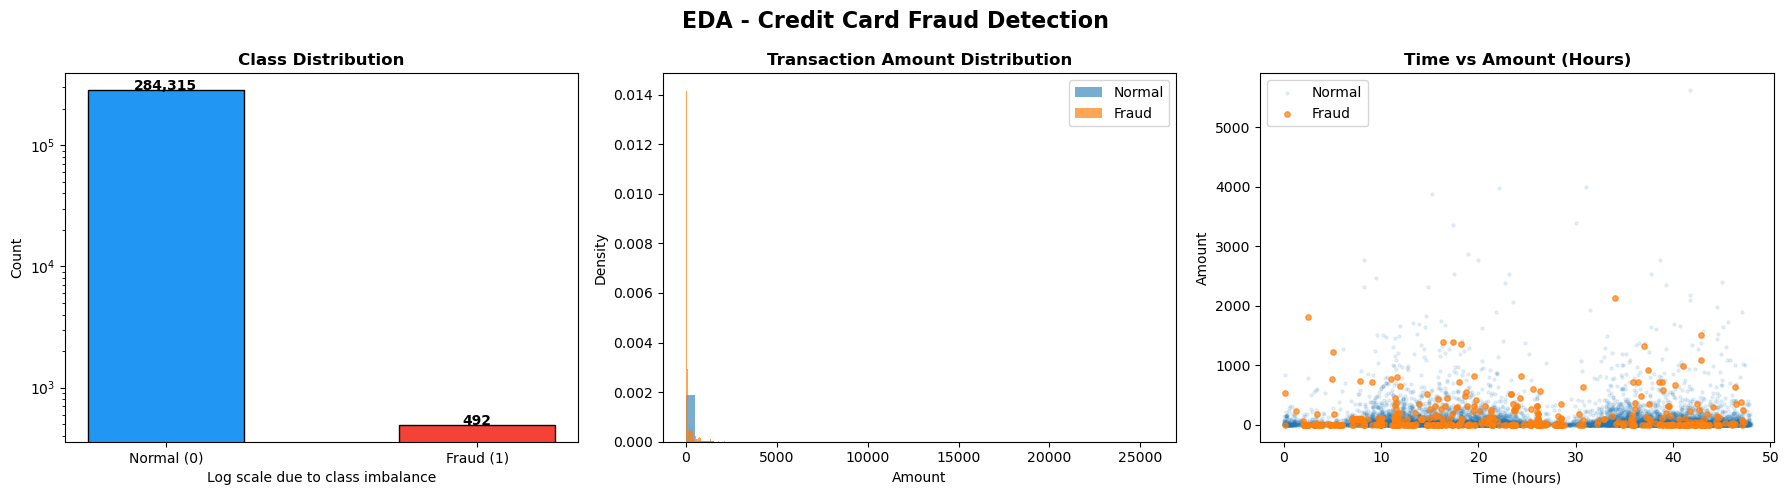


>> EDA chart saved as eda_overview.png


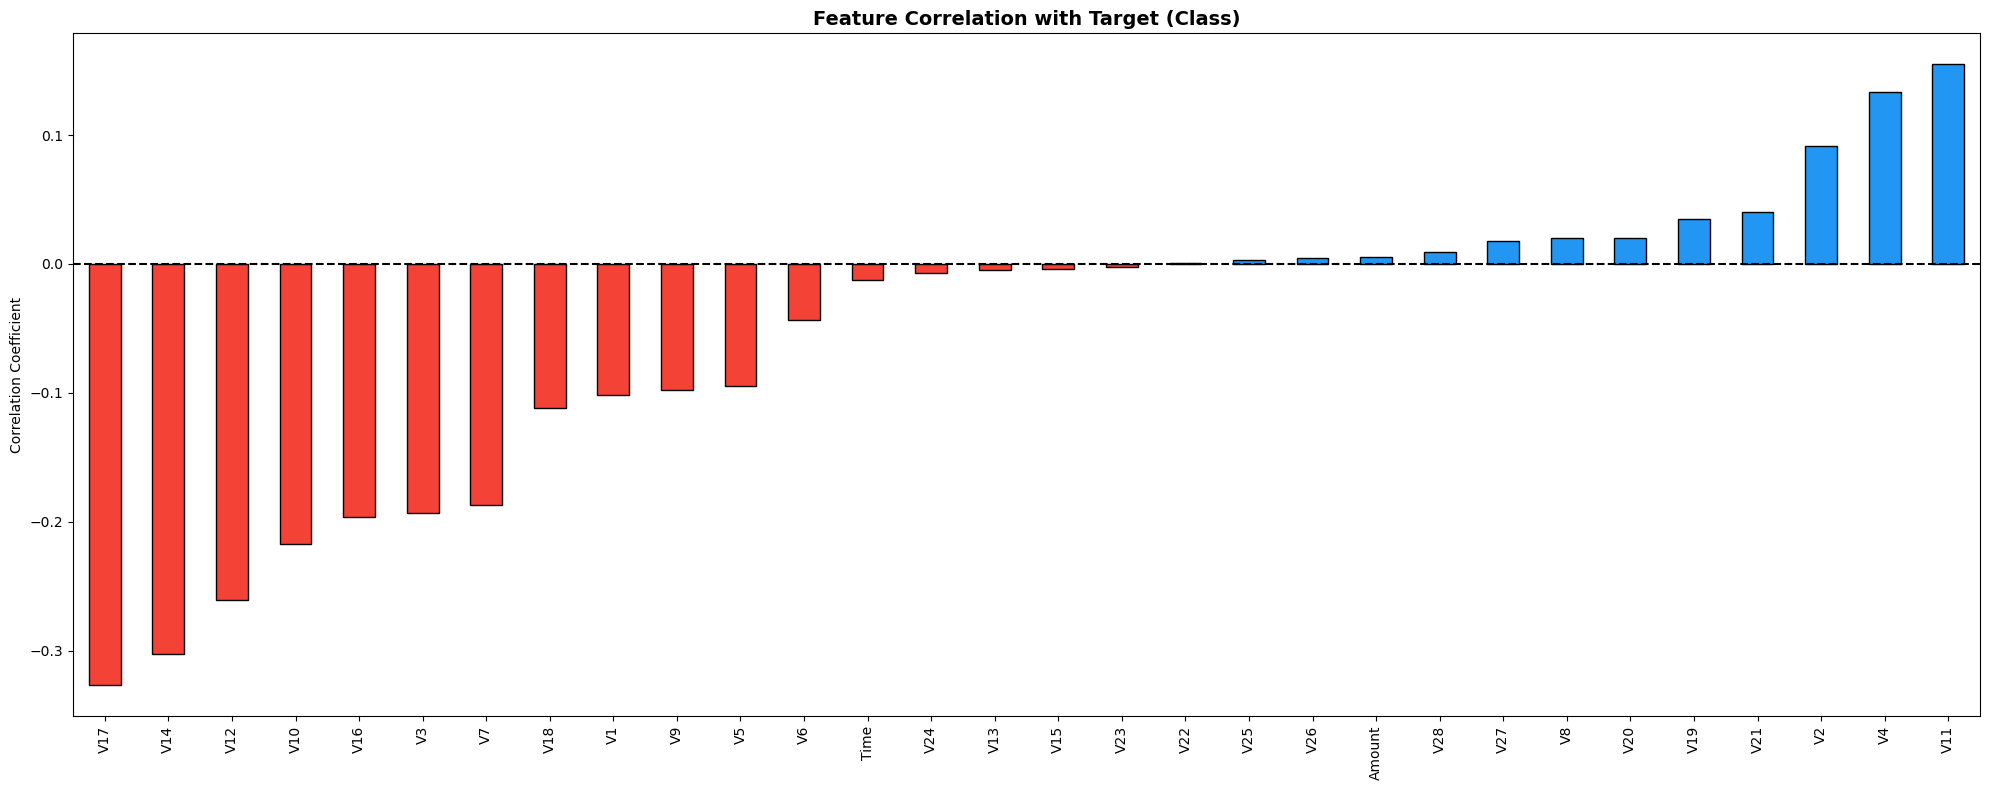


1. SEVERE CLASS IMBALANCE:
   Only 0.1727% of transactions are fraudulent 
   (~577:1 ratio), indicating a highly imbalanced dataset.
   Therefore, accuracy alone is not a reliable evaluation metric.

2. TRANSACTION AMOUNT ANALYSIS:
   Fraudulent transactions show a different distribution compared to normal transactions,
   with a lower average amount (Mean Normal: $88.29 
   vs Mean Fraud: $122.21).

3. TEMPORAL PATTERN:
   Fraudulent transactions occur throughout the time range, but may exhibit 
   slightly different patterns across certain time intervals.

4. FEATURE INSIGHTS (PCA FEATURES):
   The features V1–V28 are anonymized using PCA transformation.
   Features with higher absolute correlation with the target variable (Class)
   are more informative for detecting fraudulent transactions.



In [5]:
# --- 4.1: Class Distribution ---
class_counts = df["Class"].value_counts()
fraud_pct = (class_counts[1] / len(df)) * 100

print("\n>> Class Distribution:")
print(f"   Normal (0): {class_counts[0]:,} transactions ({100-fraud_pct:.2f}%)")
print(f"   Fraud  (1): {class_counts[1]:,} transactions ({fraud_pct:.4f}%)")
print(f"\n   Imbalance Ratio: {class_counts[0]//class_counts[1]}:1 (Normal:Fraud)")

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("EDA - Credit Card Fraud Detection", fontsize=16, fontweight="bold")

# --- Plot 1: Class Distribution ---
axes[0].bar(["Normal (0)", "Fraud (1)"], class_counts.values,
            color=["#2196F3", "#F44336"], edgecolor="black", width=0.5)
axes[0].set_title("Class Distribution", fontweight="bold")
axes[0].set_ylabel("Count")

for i, v in enumerate(class_counts.values):
    axes[0].text(i, v, f"{v:,}", ha="center", fontweight="bold")

axes[0].set_yscale("log")
axes[0].set_xlabel("Log scale due to class imbalance")

# --- Plot 2: Transaction Amount Distribution ---
fraud_amounts = df[df["Class"] == 1]["Amount"]
normal_amounts = df[df["Class"] == 0]["Amount"]

axes[1].hist(normal_amounts, bins=50, alpha=0.6, label="Normal", density=True)
axes[1].hist(fraud_amounts, bins=50, alpha=0.7, label="Fraud", density=True)

axes[1].set_title("Transaction Amount Distribution", fontweight="bold")
axes[1].set_xlabel("Amount")
axes[1].set_ylabel("Density")
axes[1].legend()

# --- Plot 3: Time vs Amount Scatter ---
# Sampling to avoid overcrowding
normal_sample = df[df["Class"] == 0].sample(n=10000, random_state=42)
fraud_sample = df[df["Class"] == 1]

axes[2].scatter(normal_sample["Time"] / 3600, normal_sample["Amount"],
                alpha=0.1, s=5, label="Normal")
axes[2].scatter(fraud_sample["Time"] / 3600, fraud_sample["Amount"],
                alpha=0.7, s=15, label="Fraud")

axes[2].set_title("Time vs Amount (Hours)", fontweight="bold")
axes[2].set_xlabel("Time (hours)")
axes[2].set_ylabel("Amount")
axes[2].legend()

plt.tight_layout()
plt.savefig("eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n>> EDA chart saved as eda_overview.png")


# --- 4.2: Feature Correlation with Target ---
plt.figure(figsize=(20, 8))

corr = df.corr()["Class"].drop("Class").sort_values()
colors = ["#F44336" if x < 0 else "#2196F3" for x in corr]

corr.plot(kind="bar", color=colors, edgecolor="black")

plt.title("Feature Correlation with Target (Class)", fontsize=14, fontweight="bold")
plt.ylabel("Correlation Coefficient")
plt.axhline(0, color="black", linestyle="--")

plt.tight_layout()
plt.show()

print(f"""
1. SEVERE CLASS IMBALANCE:
   Only {fraud_pct:.4f}% of transactions are fraudulent 
   (~{class_counts[0]//class_counts[1]}:1 ratio), indicating a highly imbalanced dataset.
   Therefore, accuracy alone is not a reliable evaluation metric.

2. TRANSACTION AMOUNT ANALYSIS:
   Fraudulent transactions show a different distribution compared to normal transactions,
   with a lower average amount (Mean Normal: ${normal_amounts.mean():.2f} 
   vs Mean Fraud: ${fraud_amounts.mean():.2f}).

3. TEMPORAL PATTERN:
   Fraudulent transactions occur throughout the time range, but may exhibit 
   slightly different patterns across certain time intervals.

4. FEATURE INSIGHTS (PCA FEATURES):
   The features V1–V28 are anonymized using PCA transformation.
   Features with higher absolute correlation with the target variable (Class)
   are more informative for detecting fraudulent transactions.
""")

In [6]:
# Define features and target
X = df.drop(columns=["Class"])
y = df["Class"]

print(f"Features (X) shape: {X.shape}")
print(f"Target  (y) shape: {y.shape}")
print(f"\nFraud in full dataset: {y.sum():,} ({y.mean()*100:.4f}%)")

# Stratified Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        
)

print(f"\nTrain set: {X_train.shape[0]:,} samples | Fraud: {y_train.sum():,} ({y_train.mean()*100:.4f}%)")
print(f"Test  set: {X_test.shape[0]:,}  samples | Fraud: {y_test.sum():,} ({y_test.mean()*100:.4f}%)")
print("\n")
print(f'''The dataset is split into training and testing sets using stratified sampling to preserve the original class distribution. 
This ensures that both sets contain a representative proportion of fraudulent transactions, which is critical for reliable model evaluation.''')

Features (X) shape: (284807, 30)
Target  (y) shape: (284807,)

Fraud in full dataset: 492 (0.1727%)

Train set: 227,845 samples | Fraud: 394 (0.1729%)
Test  set: 56,962  samples | Fraud: 98 (0.1720%)


The dataset is split into training and testing sets using stratified sampling to preserve the original class distribution. 
This ensures that both sets contain a representative proportion of fraudulent transactions, which is critical for reliable model evaluation.


In [7]:
# Scale Amount and Time (V1-V28 are already PCA scaled)
scaler = StandardScaler()

# Fit ONLY on training data, then transform both sets
X_train[["Amount", "Time"]] = scaler.fit_transform(X_train[["Amount", "Time"]])
X_test[["Amount", "Time"]]  = scaler.transform(X_test[["Amount", "Time"]])

print(">> Scaled 'Amount' and 'Time' columns using StandardScaler")
print(">> Fit ONLY on training data to prevent data leakage")
print(f"\nAmount stats after scaling (Train):")
print(f"   Mean: {X_train['Amount'].mean():.4f}  |  Std: {X_train['Amount'].std():.4f}")
print("\n")
print(f'''Feature scaling is applied to the ‘Amount’ and ‘Time’ features using StandardScaler to bring them to a common scale. 
This helps models like Logistic Regression perform better, while PCA-transformed features (V1–V28) are already standardized.''')

>> Scaled 'Amount' and 'Time' columns using StandardScaler
>> Fit ONLY on training data to prevent data leakage

Amount stats after scaling (Train):
   Mean: 0.0000  |  Std: 1.0000


Feature scaling is applied to the ‘Amount’ and ‘Time’ features using StandardScaler to bring them to a common scale. 
This helps models like Logistic Regression perform better, while PCA-transformed features (V1–V28) are already standardized.


In [8]:
print(f"Before SMOTE (Training set):")
print(f"   Normal: {(y_train==0).sum():,}  |  Fraud: {(y_train==1).sum():,}")

# Apply SMOTE ONLY on training data — NEVER on test data
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE (Training set):")
print(f"   Normal: {(y_train_sm==0).sum():,}  |  Fraud: {(y_train_sm==1).sum():,}")
print(f"\n>> Test set remains UNTOUCHED (real-world distribution preserved)")
print(f">> Total training samples after SMOTE: {len(X_train_sm):,}")
print(f"\nClass balance after SMOTE:")
print(y_train_sm.value_counts())

Before SMOTE (Training set):
   Normal: 227,451  |  Fraud: 394

After SMOTE (Training set):
   Normal: 227,451  |  Fraud: 227,451

>> Test set remains UNTOUCHED (real-world distribution preserved)
>> Total training samples after SMOTE: 454,902

Class balance after SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


In [9]:
# 1. Logistic Regression (Baseline)
print("\n[1/4] Training Logistic Regression...")

lr_model = LogisticRegression(max_iter=1000, random_state=42)

lr_model.fit(X_train_sm, y_train_sm)

print("     Done!")


[1/4] Training Logistic Regression...
     Done!


In [10]:
# 2. Random Forest (Ensemble)
print("[2/4] Training Random Forest...")

rf_model = RandomForestClassifier(
   n_estimators=50,
    max_depth=10,
    random_state=42,
    n_jobs=1   
)

rf_model.fit(X_train_sm, y_train_sm)

print("     Done!")

[2/4] Training Random Forest...
     Done!


In [11]:
# 3. XGBoost (Boosting)
print("[3/4] Training XGBoost...")

xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric="logloss",
    use_label_encoder=False,
    n_jobs=1   
)

xgb_model.fit(X_train_sm, y_train_sm)

print("     Done!")

[3/4] Training XGBoost...
     Done!


In [12]:
# 4. Isolation Forest (Unsupervised Anomaly Detection)
print("[4/4] Training Isolation Forest...")

iso_model = IsolationForest(
    n_estimators=100,
    contamination=0.002,
    random_state=42,
    n_jobs=1   # fixed
)
iso_model.fit(X_train)

print("     Done!")

[4/4] Training Isolation Forest...
     Done!


In [13]:
# Supervised models
lr_pred   = lr_model.predict(X_test)
rf_pred   = rf_model.predict(X_test)
xgb_pred  = xgb_model.predict(X_test)

# Probability scores for ROC/PR curves
lr_prob   = lr_model.predict_proba(X_test)[:, 1]
rf_prob   = rf_model.predict_proba(X_test)[:, 1]
xgb_prob  = xgb_model.predict_proba(X_test)[:, 1]

# Isolation Forest: -1 = anomaly (fraud) -> 1; 1 = normal -> 0
iso_raw   = iso_model.predict(X_test)
iso_pred  = (iso_raw == -1).astype(int)
iso_score = -iso_model.score_samples(X_test)  

print("Predictions generated for all 4 models.")
print("Isolation Forest: converted -1 → 1 (fraud) and 1 → 0 (normal)")
print("\nShape check:")
print(f"y_test: {y_test.shape}")
print(f"LR preds: {lr_pred.shape}")
print(f"RF preds: {rf_pred.shape}")
print(f"XGB preds: {xgb_pred.shape}")
print(f"ISO preds: {iso_pred.shape}")

Predictions generated for all 4 models.
Isolation Forest: converted -1 → 1 (fraud) and 1 → 0 (normal)

Shape check:
y_test: (56962,)
LR preds: (56962,)
RF preds: (56962,)
XGB preds: (56962,)
ISO preds: (56962,)


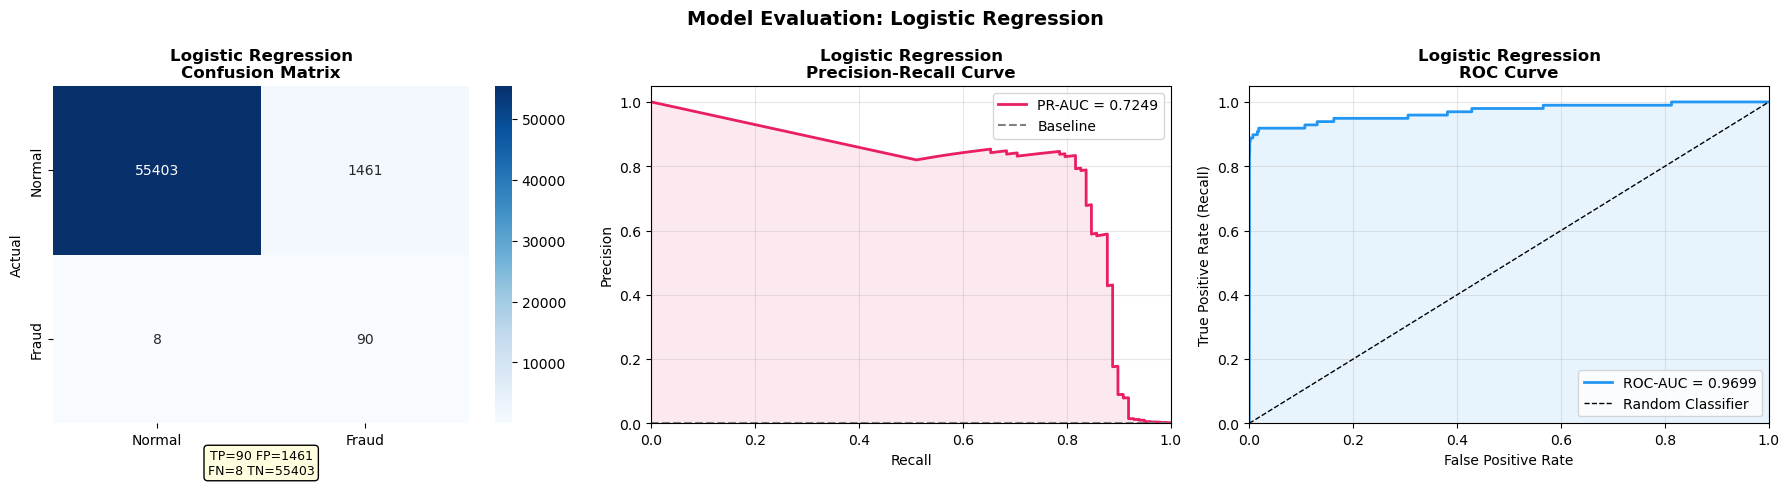


Logistic Regression Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



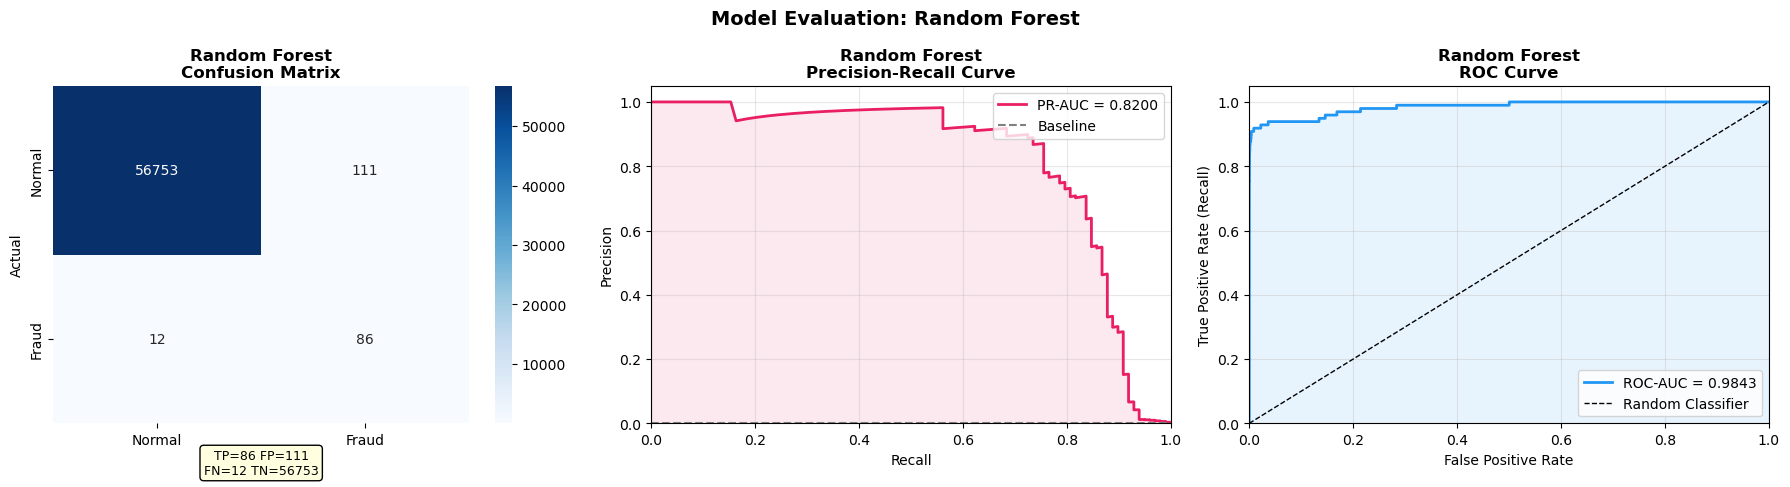


Random Forest Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.44      0.88      0.58        98

    accuracy                           1.00     56962
   macro avg       0.72      0.94      0.79     56962
weighted avg       1.00      1.00      1.00     56962



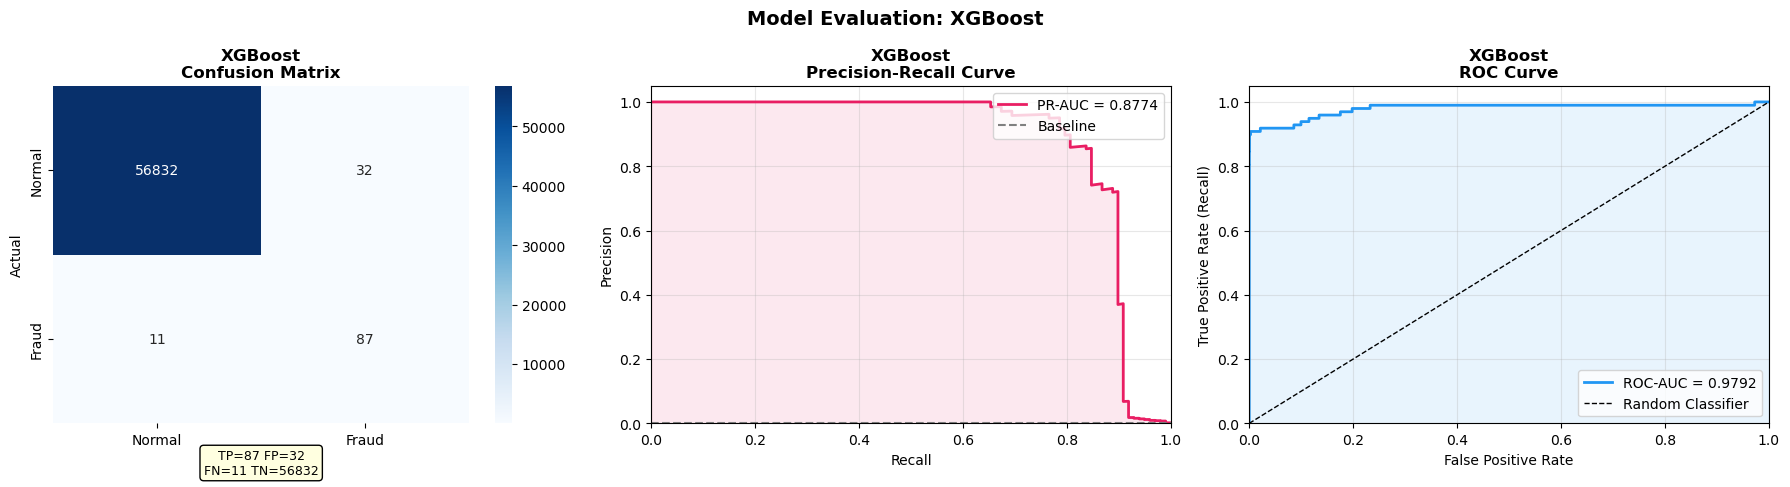


XGBoost Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.73      0.89      0.80        98

    accuracy                           1.00     56962
   macro avg       0.87      0.94      0.90     56962
weighted avg       1.00      1.00      1.00     56962



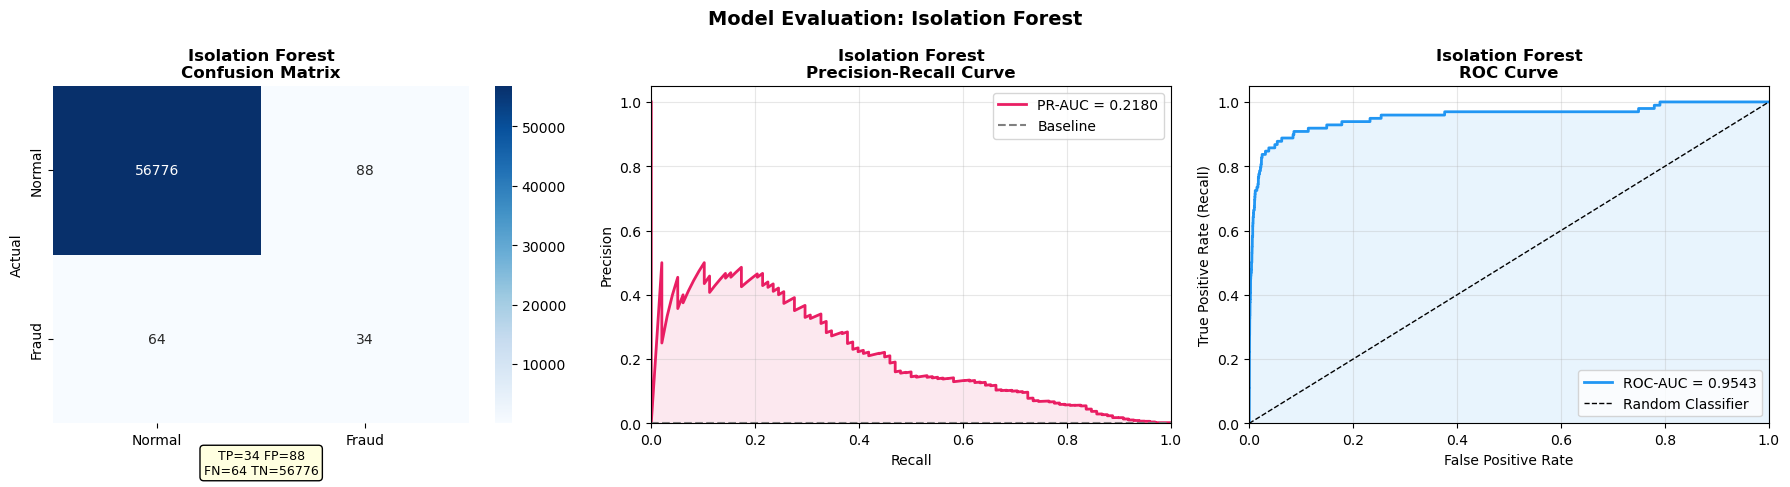


Isolation Forest Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.28      0.35      0.31        98

    accuracy                           1.00     56962
   macro avg       0.64      0.67      0.65     56962
weighted avg       1.00      1.00      1.00     56962


Final Model Comparison (sorted by Recall):
                 Model  Precision  Recall  F1-Score  PR-AUC  ROC-AUC
0  Logistic Regression     0.0580  0.9184    0.1092  0.7249   0.9699
2              XGBoost     0.7311  0.8878    0.8018  0.8774   0.9792
1        Random Forest     0.4365  0.8776    0.5831  0.8200   0.9843
3     Isolation Forest     0.2787  0.3469    0.3091  0.2180   0.9543


In [14]:
def evaluate_model(name, y_true, y_pred, y_prob, ax_cm, ax_pr, ax_roc):
    """Full evaluation: metrics + confusion matrix + PR curve + ROC curve"""

    # Core metrics
    prec  = precision_score(y_true, y_pred, zero_division=0)
    rec   = recall_score(y_true, y_pred, zero_division=0)
    f1    = f1_score(y_true, y_pred, zero_division=0)
    pr_auc = average_precision_score(y_true, y_prob)
    roc_auc = roc_auc_score(y_true, y_prob)

    # --- Confusion Matrix ---
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax_cm,
                xticklabels=["Normal", "Fraud"], yticklabels=["Normal", "Fraud"])
    ax_cm.set_title(f"{name}\nConfusion Matrix", fontweight="bold")
    ax_cm.set_ylabel("Actual")
    ax_cm.set_xlabel("Predicted")

    tn, fp, fn, tp = cm.ravel()
    ax_cm.text(0.5, -0.15,
               f"TP={tp} FP={fp}\nFN={fn} TN={tn}",
               ha="center", transform=ax_cm.transAxes, fontsize=9,
               bbox=dict(boxstyle="round", facecolor="lightyellow"))

    # --- Precision-Recall Curve ---
    precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_prob)
    ax_pr.plot(recall_vals, precision_vals, color="#E91E63", lw=2,
               label=f"PR-AUC = {pr_auc:.4f}")
    ax_pr.fill_between(recall_vals, precision_vals, alpha=0.1, color="#E91E63")

    # Baseline line (important for imbalanced data)
    ax_pr.plot([0, 1], [y_true.mean(), y_true.mean()],
               linestyle="--", color="gray", label="Baseline")

    ax_pr.set_xlim([0, 1])
    ax_pr.set_ylim([0, 1.05])
    ax_pr.set_xlabel("Recall")
    ax_pr.set_ylabel("Precision")
    ax_pr.set_title(f"{name}\nPrecision-Recall Curve", fontweight="bold")
    ax_pr.legend(loc="upper right")
    ax_pr.grid(alpha=0.3)

    # --- ROC Curve ---
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    ax_roc.plot(fpr, tpr, color="#2196F3", lw=2, label=f"ROC-AUC = {roc_auc:.4f}")
    ax_roc.fill_between(fpr, tpr, alpha=0.1, color="#2196F3")
    ax_roc.plot([0, 1], [0, 1], "k--", lw=1, label="Random Classifier")

    ax_roc.set_xlim([0, 1])
    ax_roc.set_ylim([0, 1.05])
    ax_roc.set_xlabel("False Positive Rate")
    ax_roc.set_ylabel("True Positive Rate (Recall)")
    ax_roc.set_title(f"{name}\nROC Curve", fontweight="bold")
    ax_roc.legend(loc="lower right")
    ax_roc.grid(alpha=0.3)

    return {
        "Model": name,
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "PR-AUC": round(pr_auc, 4),
        "ROC-AUC": round(roc_auc, 4)
    }


# Evaluate all models
models_info = [
    ("Logistic Regression", lr_pred, lr_prob),
    ("Random Forest",       rf_pred, rf_prob),
    ("XGBoost",             xgb_pred, xgb_prob),
    ("Isolation Forest",    iso_pred, iso_score),
]

results = []

for name, pred, prob in models_info:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Model Evaluation: {name}", fontsize=14, fontweight="bold")

    result = evaluate_model(name, y_test, pred, prob, axes[0], axes[1], axes[2])
    results.append(result)

    plt.tight_layout()
    safe_name = name.lower().replace(" ", "_")
    plt.savefig(f"eval_{safe_name}.png", dpi=150, bbox_inches="tight")
    plt.show()

    print(f"\n{name} Classification Report:")
    print(classification_report(y_test, pred, target_names=["Normal", "Fraud"]))


results_df = pd.DataFrame(results)

print("\nFinal Model Comparison (sorted by Recall):")
print(results_df.sort_values(by="Recall", ascending=False))

                     Precision  Recall  F1-Score  PR-AUC  ROC-AUC
Model                                                            
Logistic Regression     0.0580  0.9184    0.1092  0.7249   0.9699
Random Forest           0.4365  0.8776    0.5831  0.8200   0.9843
XGBoost                 0.7311  0.8878    0.8018  0.8774   0.9792
Isolation Forest        0.2787  0.3469    0.3091  0.2180   0.9543

>> Best PR-AUC:  ['XGBoost']  (0.8774)
>> Best Recall:  ['Logistic Regression']  (0.9184)


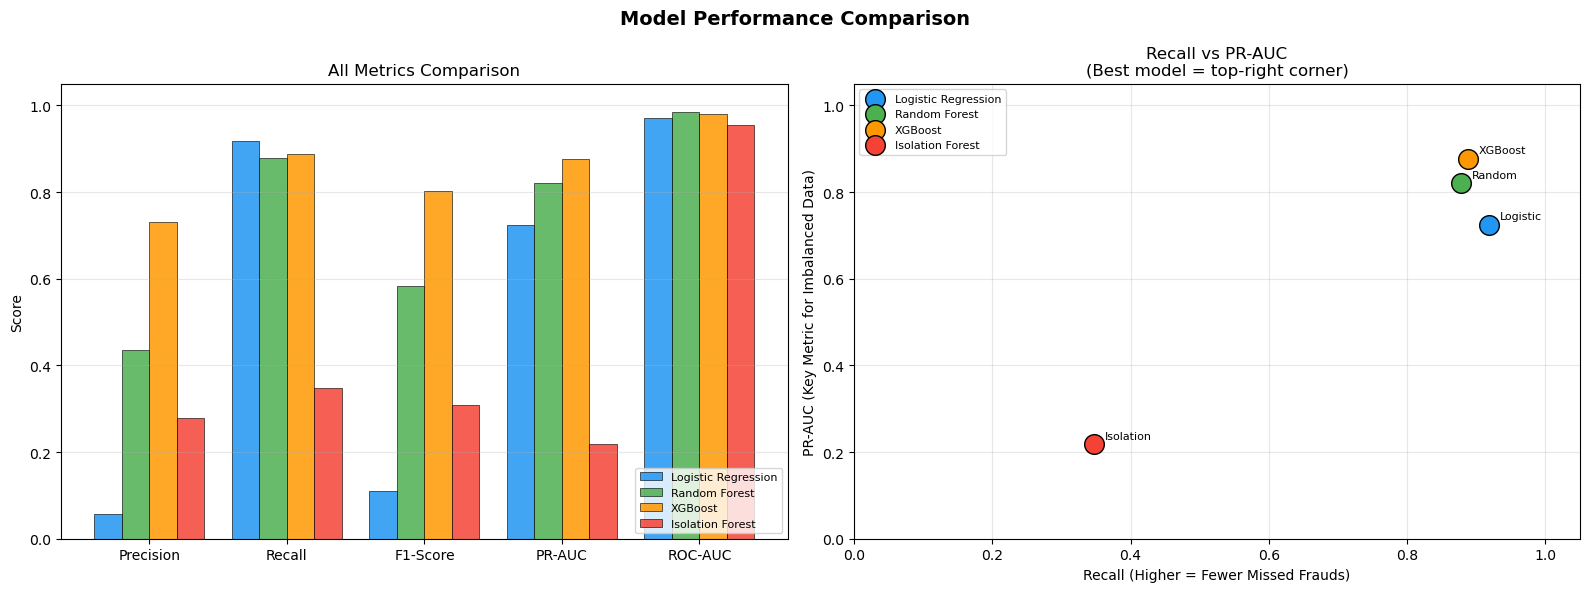

In [15]:
comparison_df = pd.DataFrame(results).set_index("Model").round(4)
print(comparison_df.to_string())

# Best models (tie-safe)
best_prauc_models = comparison_df[comparison_df["PR-AUC"] == comparison_df["PR-AUC"].max()].index.tolist()
best_recall_models = comparison_df[comparison_df["Recall"] == comparison_df["Recall"].max()].index.tolist()

print(f"\n>> Best PR-AUC:  {best_prauc_models}  ({comparison_df['PR-AUC'].max():.4f})")
print(f">> Best Recall:  {best_recall_models}  ({comparison_df['Recall'].max():.4f})")

# Visual Comparison Chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Model Performance Comparison", fontsize=14, fontweight="bold")

metrics = ["Precision", "Recall", "F1-Score", "PR-AUC", "ROC-AUC"]
x = np.arange(len(metrics))

n_models = len(comparison_df)
width = 0.8 / n_models
offset = (n_models - 1) / 2
colors_bar = ["#2196F3", "#4CAF50", "#FF9800", "#F44336"]

for i, (model_name, row) in enumerate(comparison_df.iterrows()):
    values = [row[m] for m in metrics]
    axes[0].bar(x + (i - offset) * width, values, width,
                label=model_name,
                color=colors_bar[i % len(colors_bar)],
                alpha=0.85, edgecolor="black", linewidth=0.5)

axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].set_ylabel("Score")
axes[0].set_title("All Metrics Comparison")
axes[0].legend(loc="lower right", fontsize=8)
axes[0].set_ylim(0, 1.05)
axes[0].grid(axis="y", alpha=0.3)

# Recall vs PR-AUC scatter
for i, (model_name, row) in enumerate(comparison_df.iterrows()):
    axes[1].scatter(row["Recall"], row["PR-AUC"], s=200,
                    color=colors_bar[i % len(colors_bar)],
                    label=model_name, zorder=5, edgecolors="black")
    axes[1].annotate(model_name.split()[0], (row["Recall"], row["PR-AUC"]),
                     textcoords="offset points", xytext=(8, 4), fontsize=8)

axes[1].set_xlabel("Recall (Higher = Fewer Missed Frauds)")
axes[1].set_ylabel("PR-AUC (Key Metric for Imbalanced Data)")
axes[1].set_title("Recall vs PR-AUC\n(Best model = top-right corner)")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)
axes[1].set_xlim(0, 1.05)
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()